In this notebook, we evaluate our model for zero shot super resolution. It includes:
- Finite element data for testing.
- FNO inference.
- Results comparisons.

### General Libraries

In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time
from pathlib import Path

### Microstructures

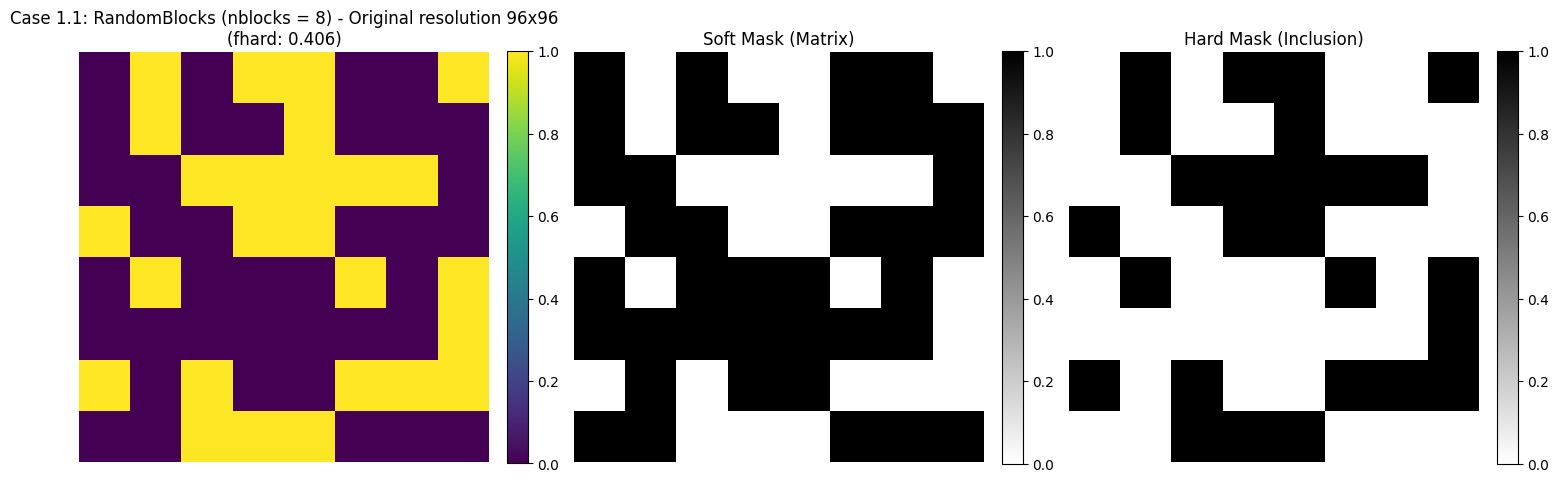

Microstructure resized: 96x96 → 192x192


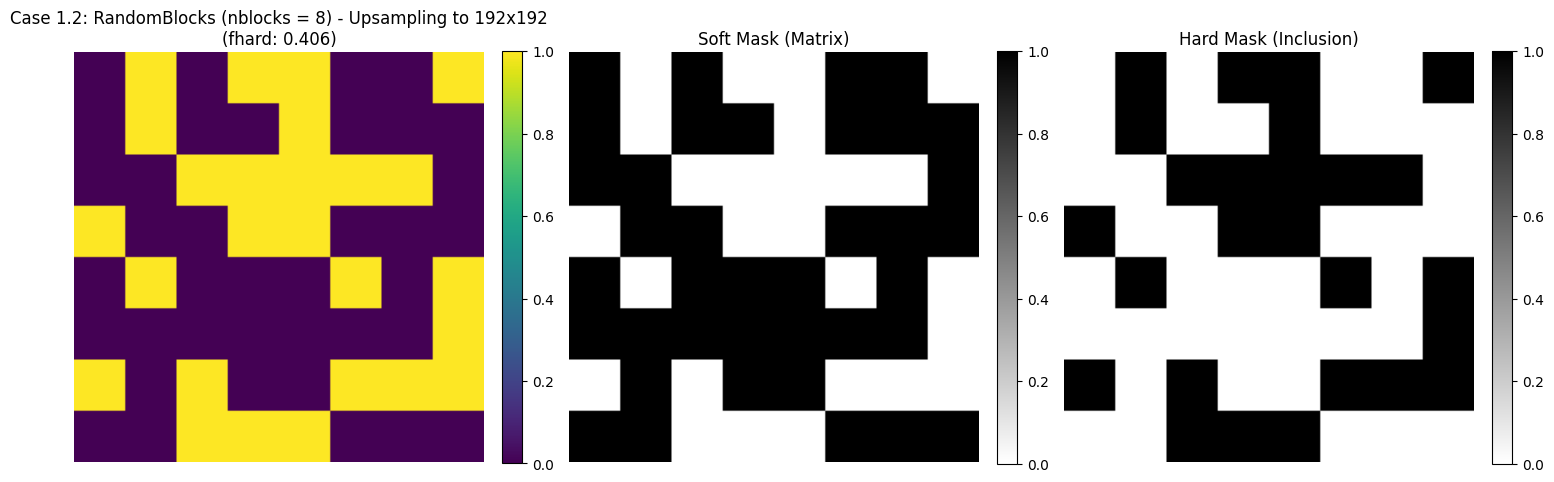

Microstructure resized: 192x192 → 48x48


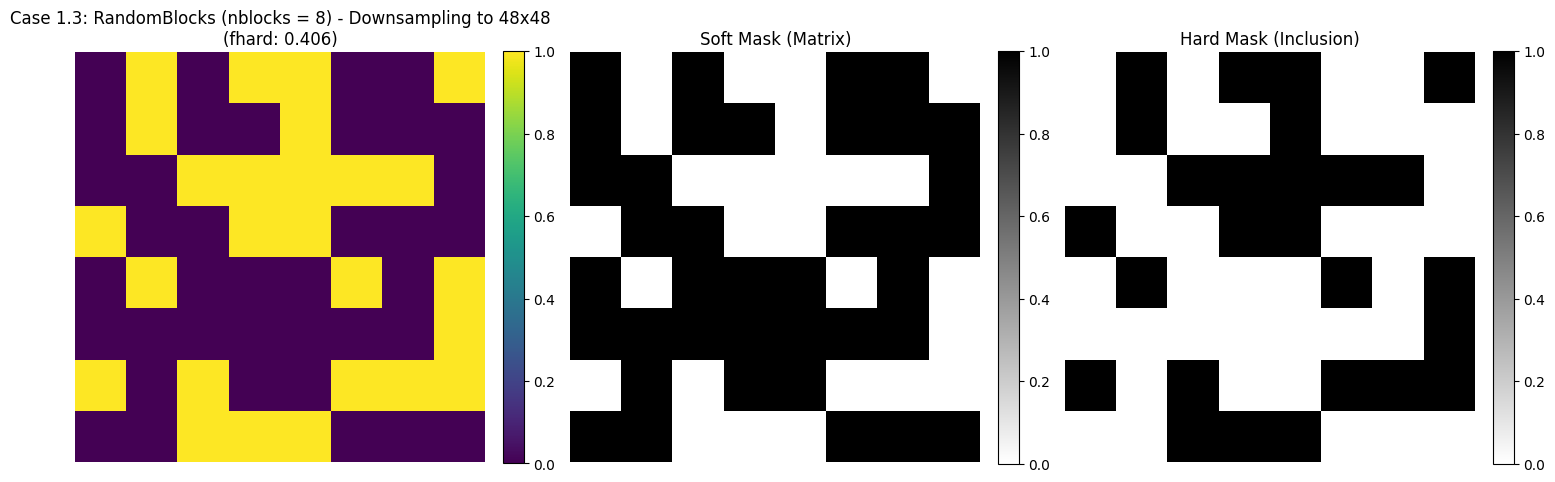

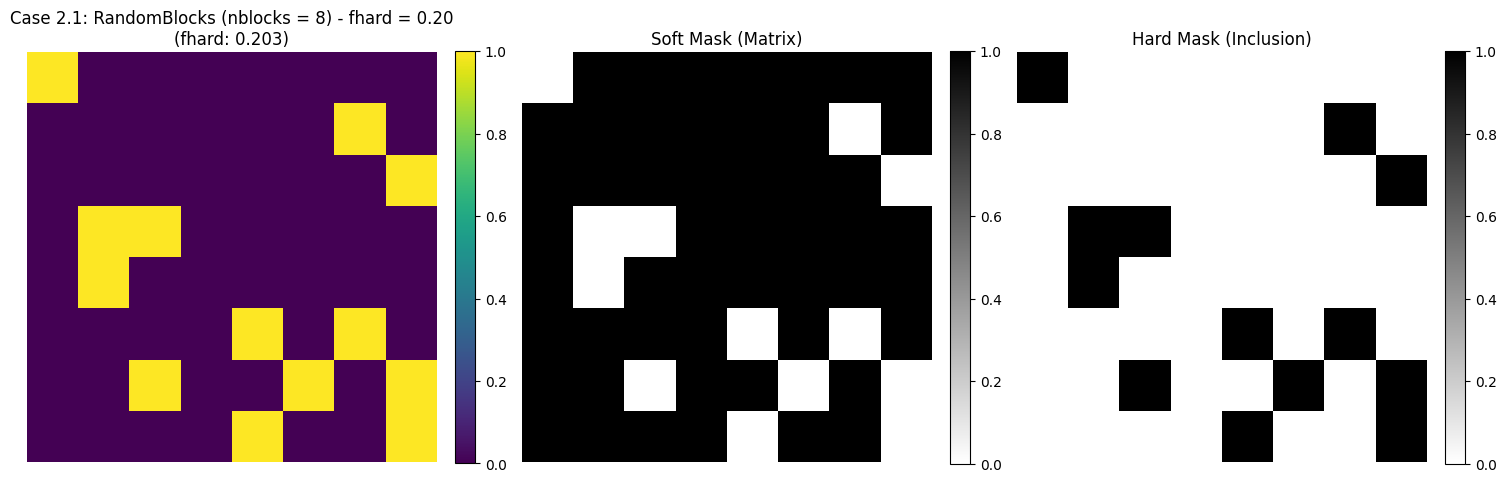

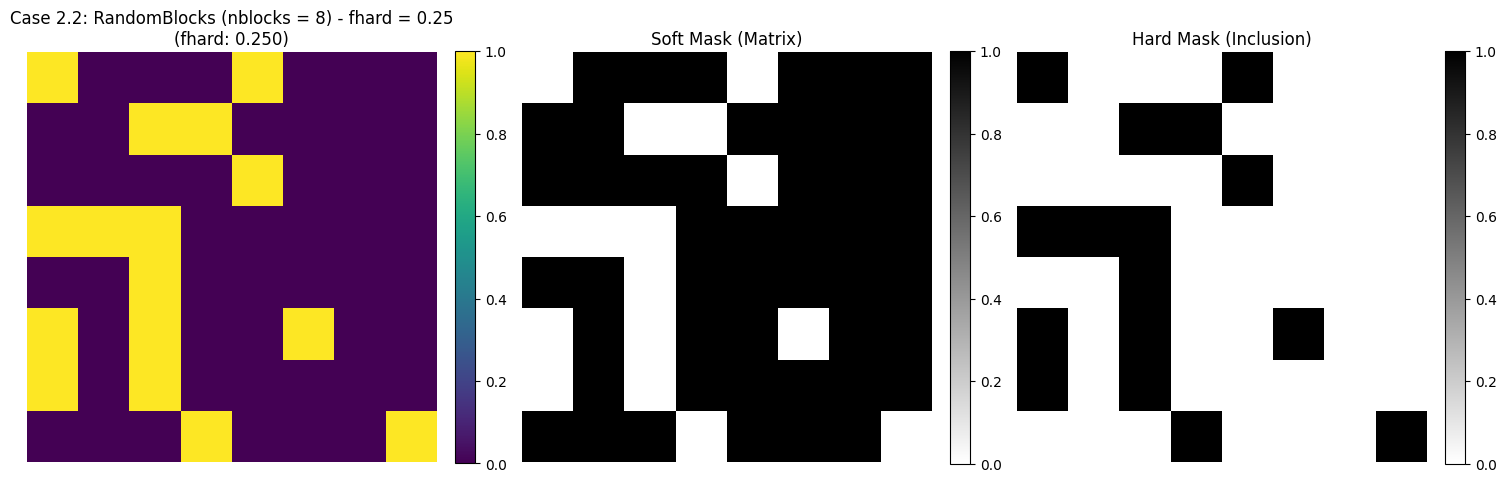

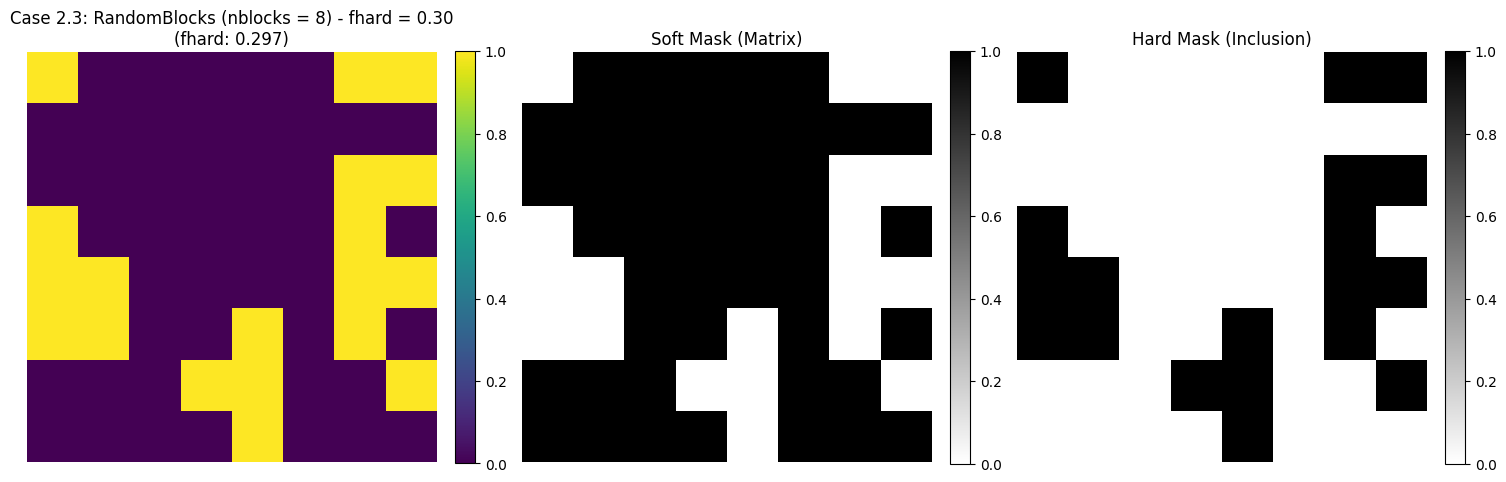

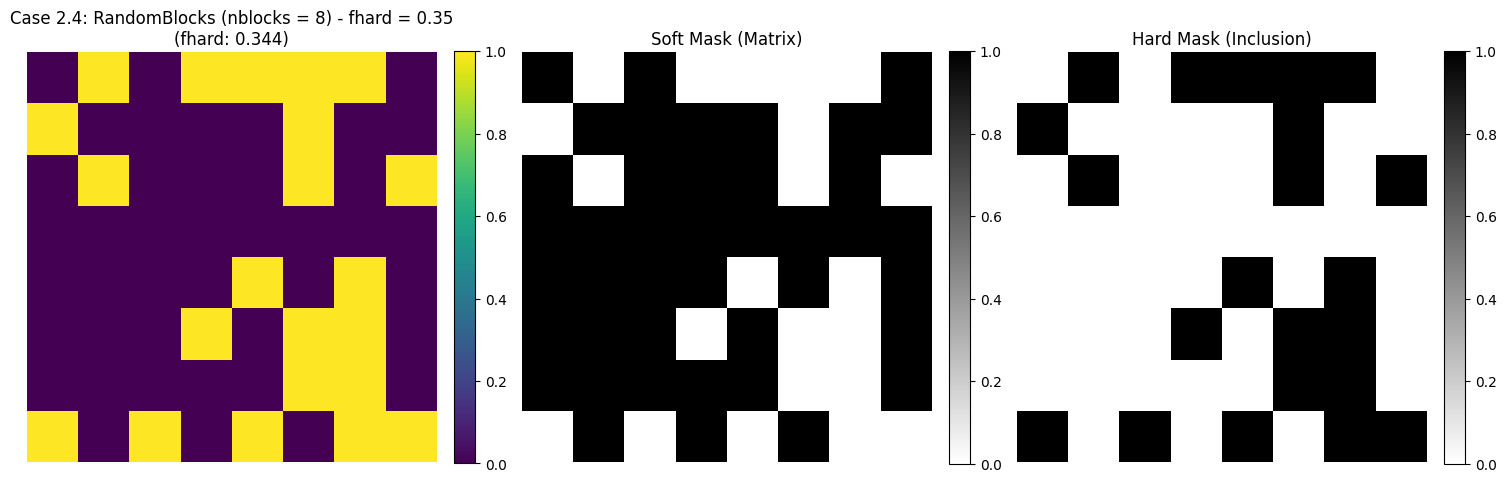

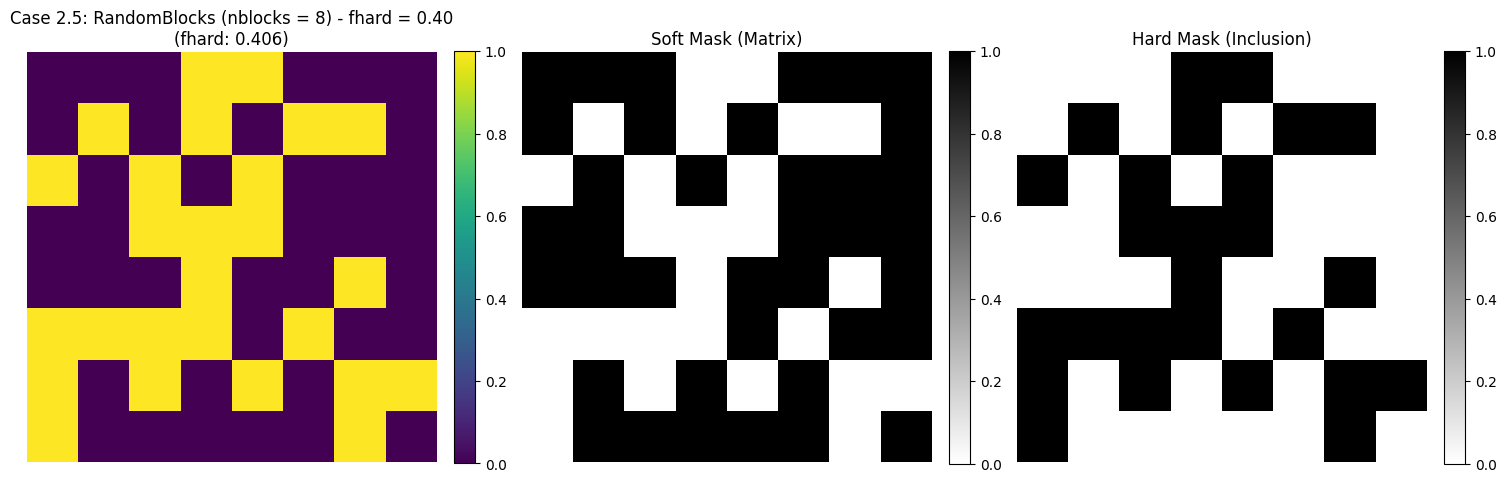

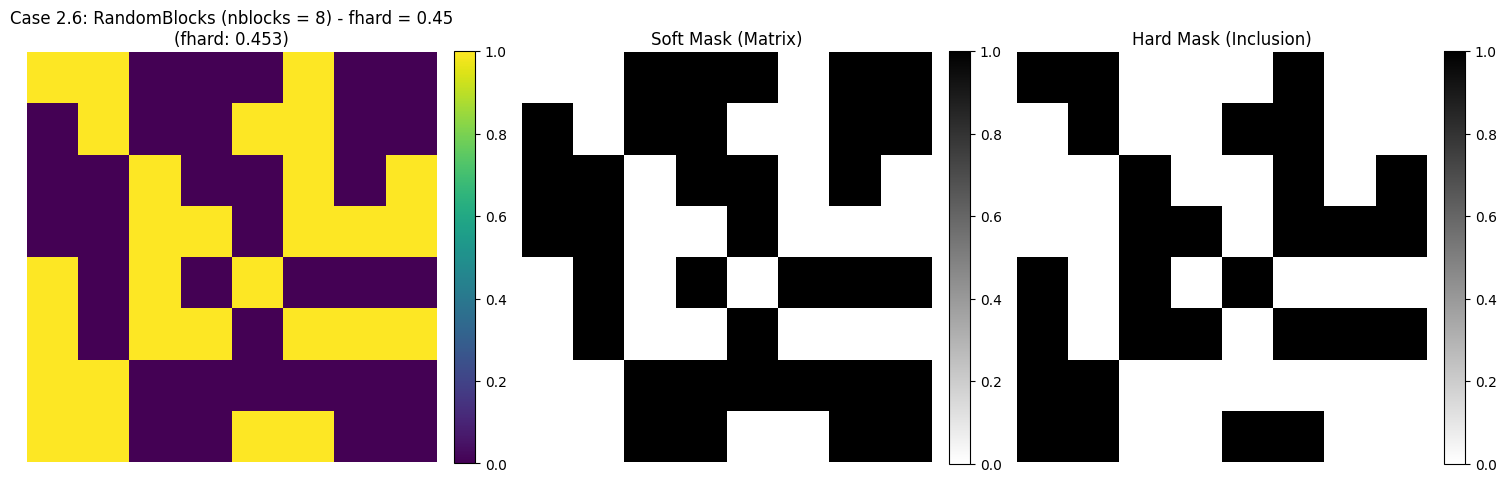

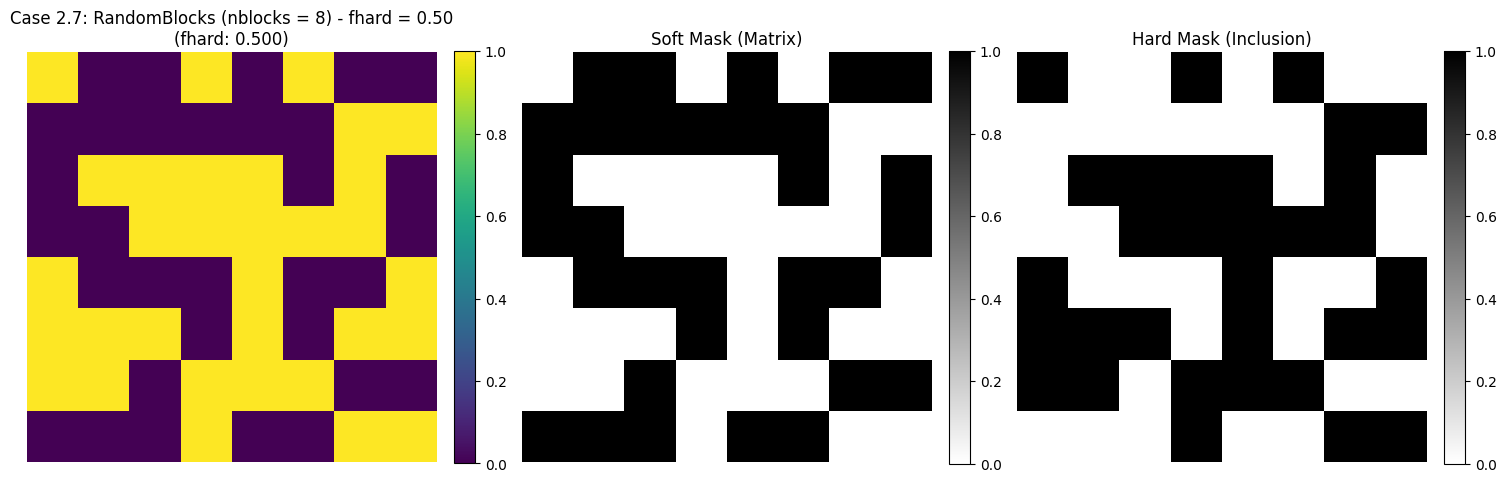

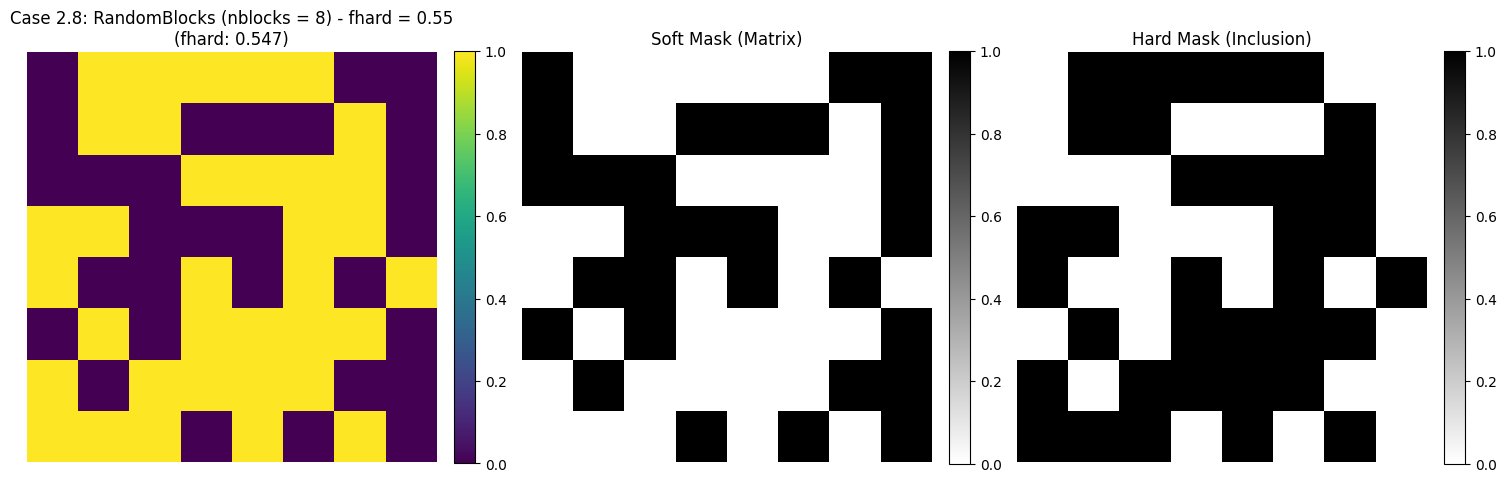

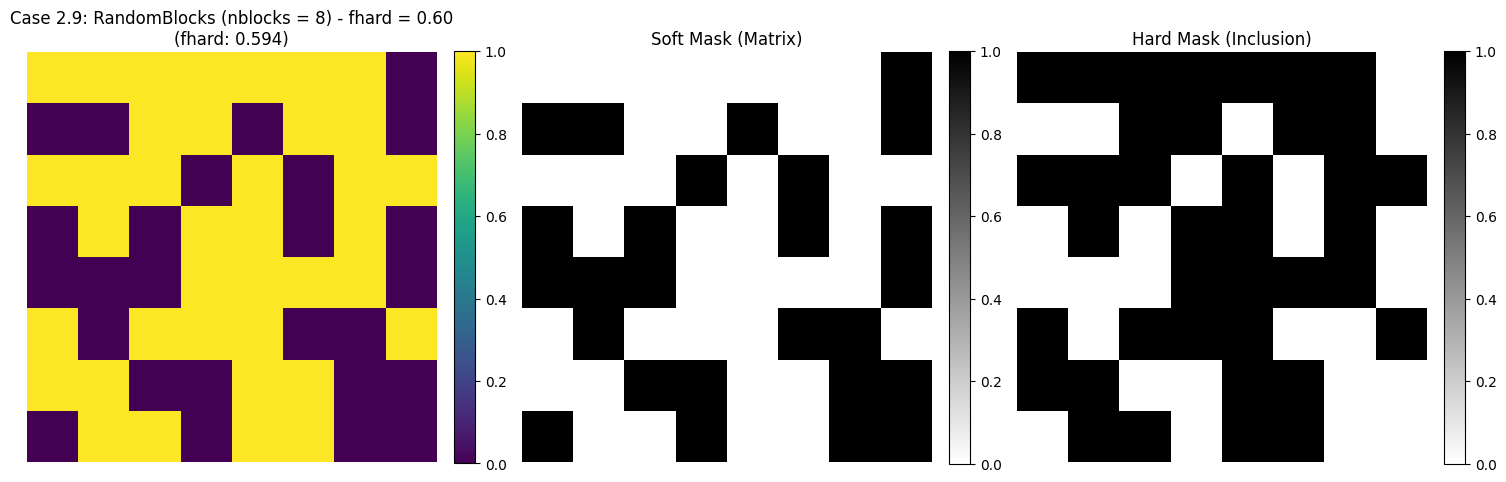

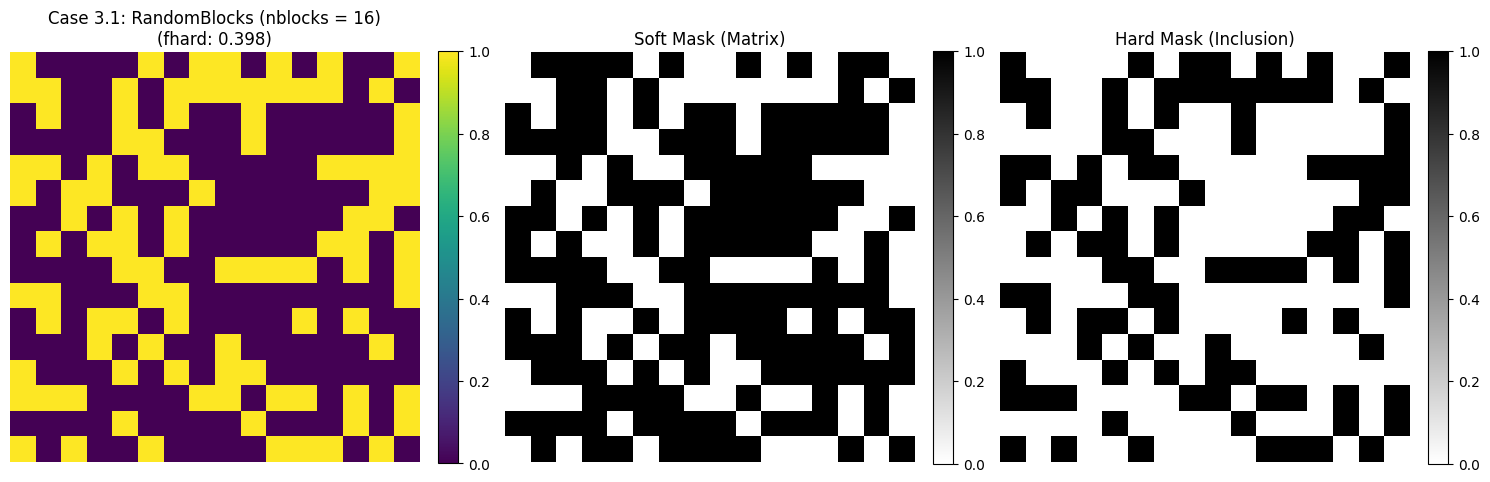

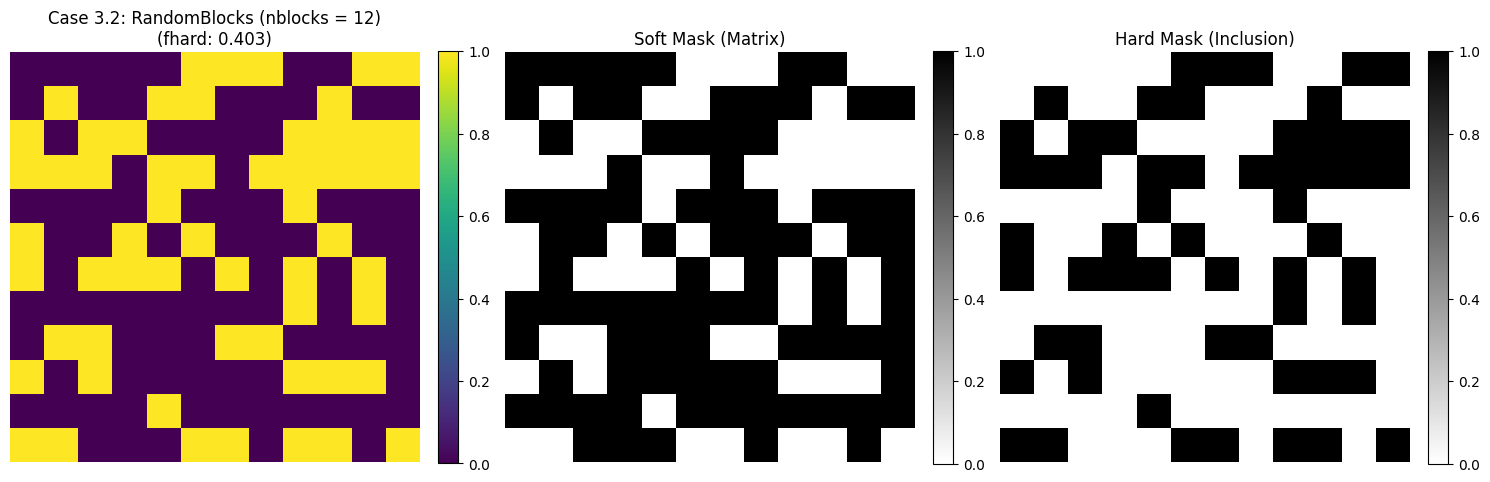

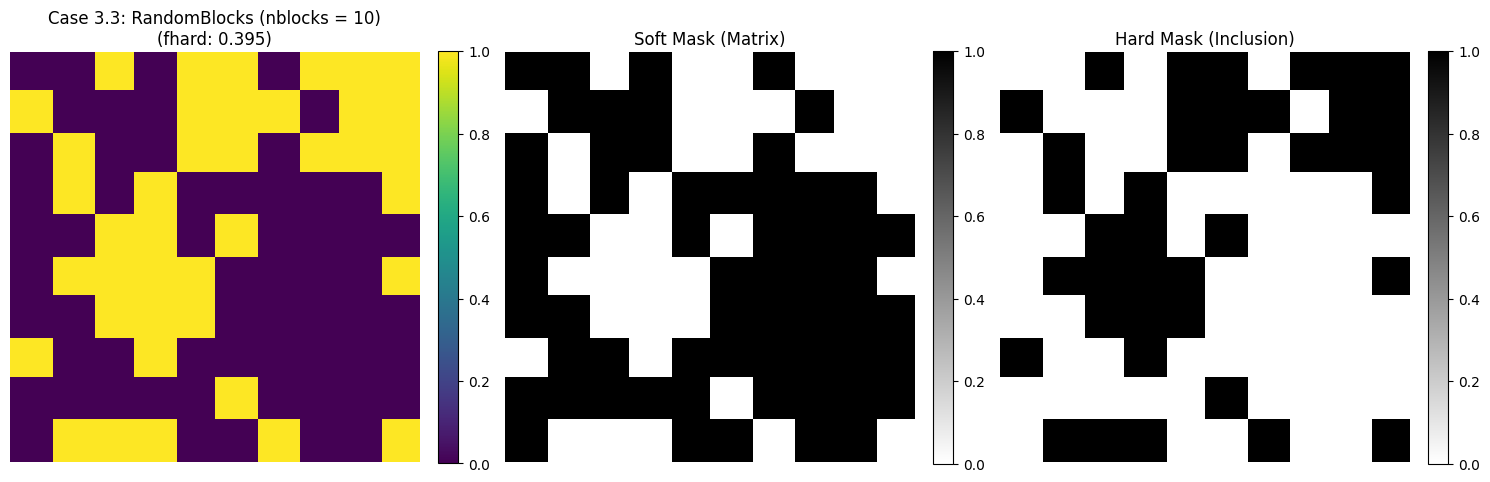

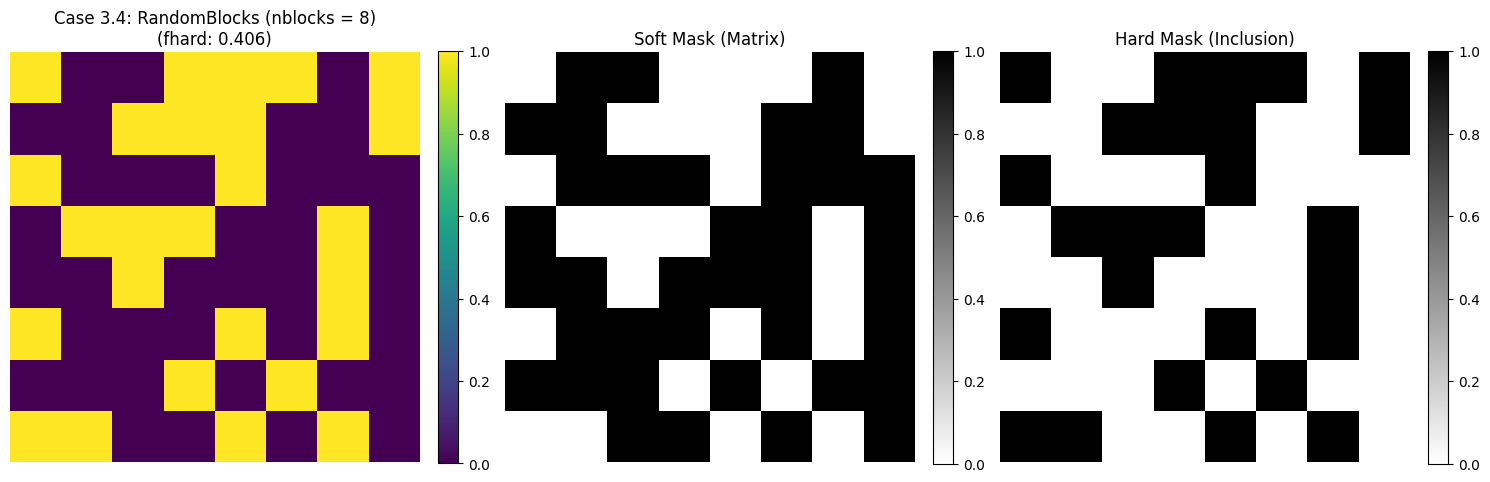

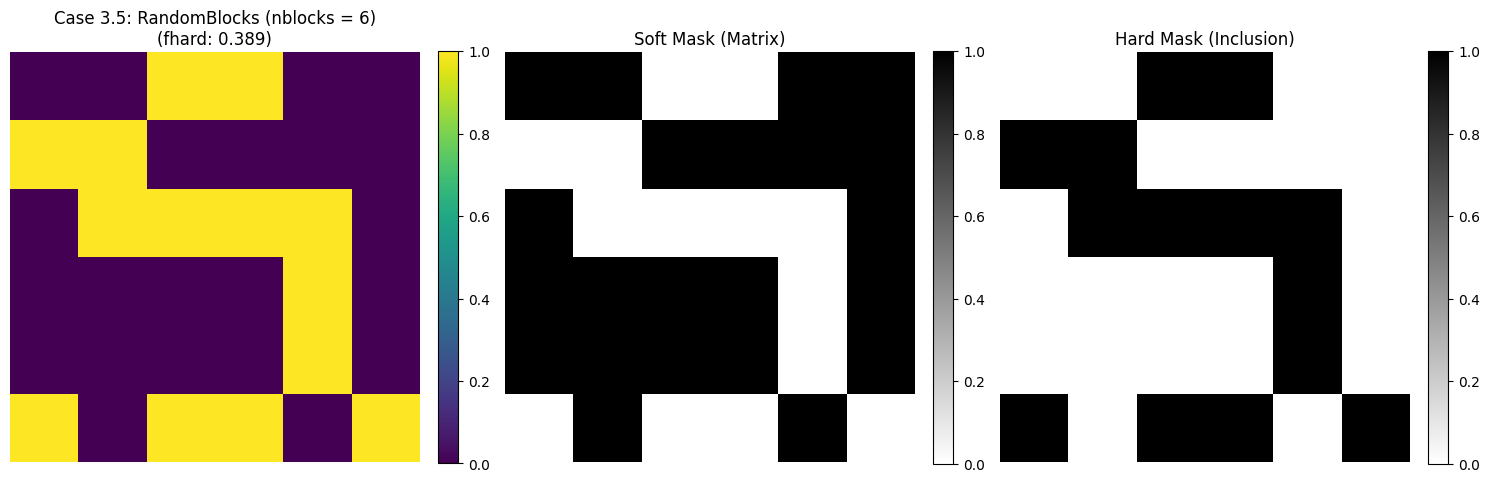

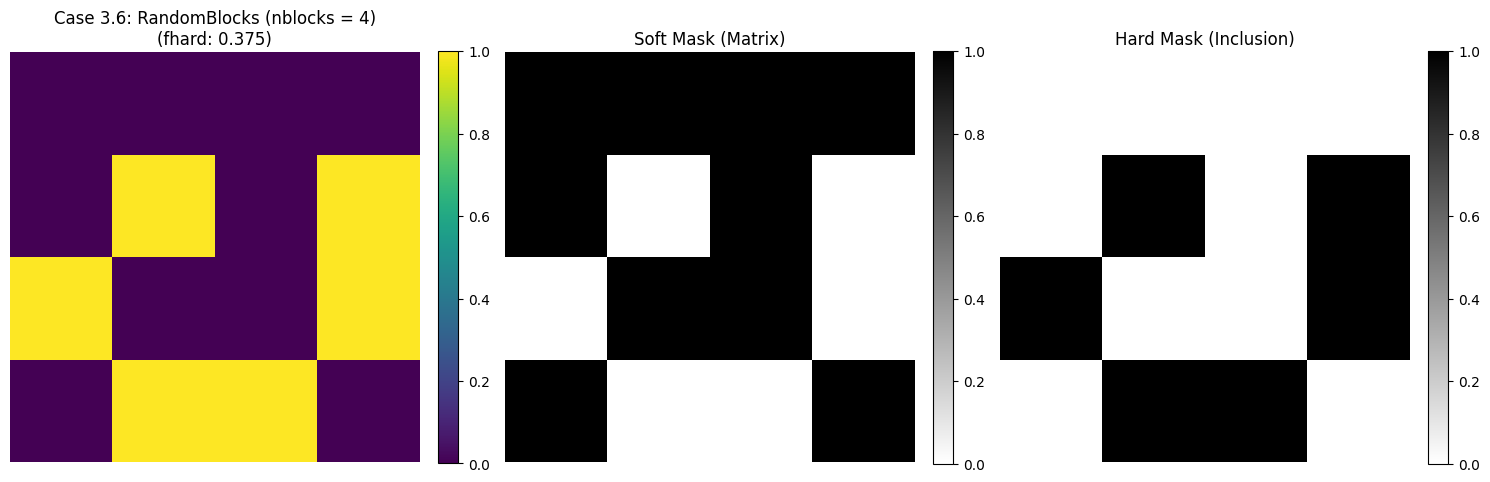

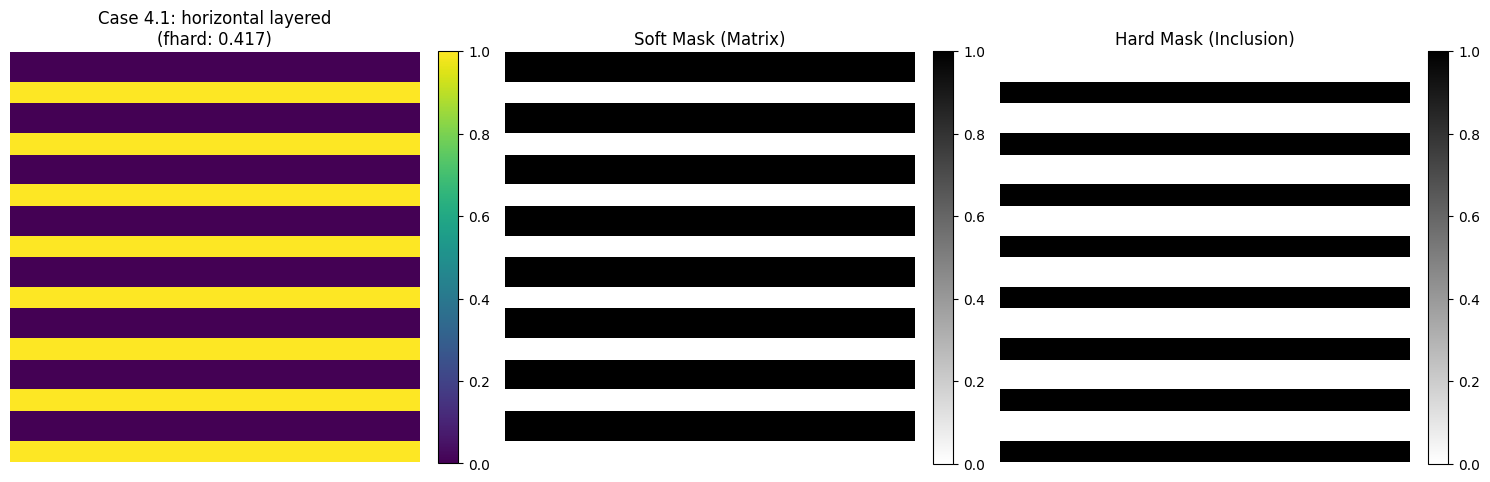

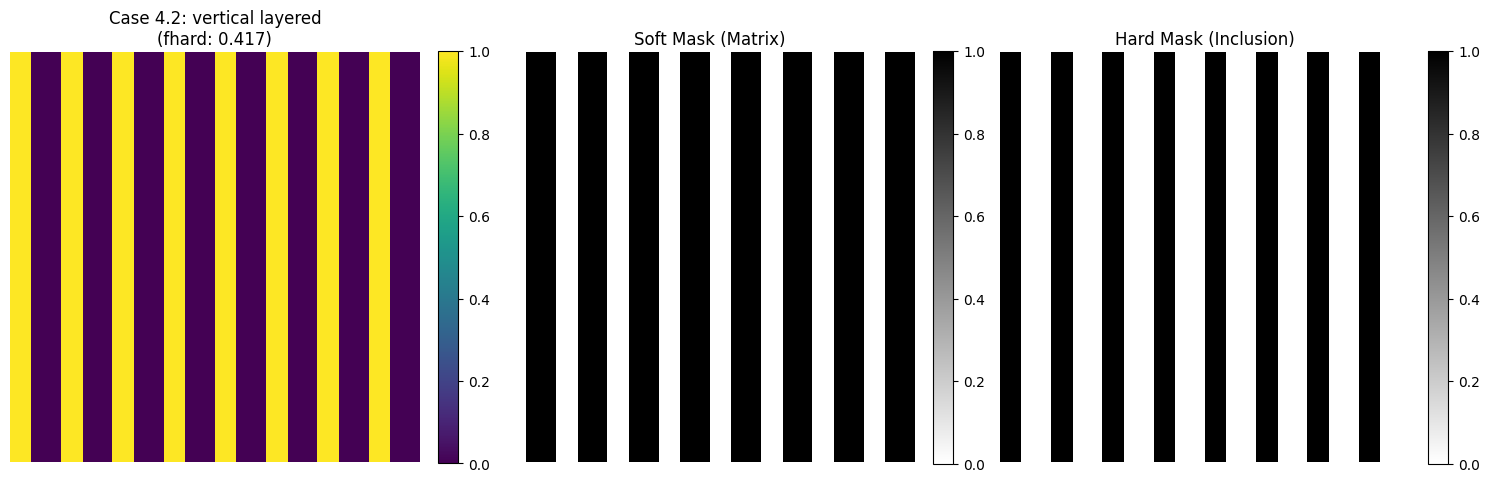

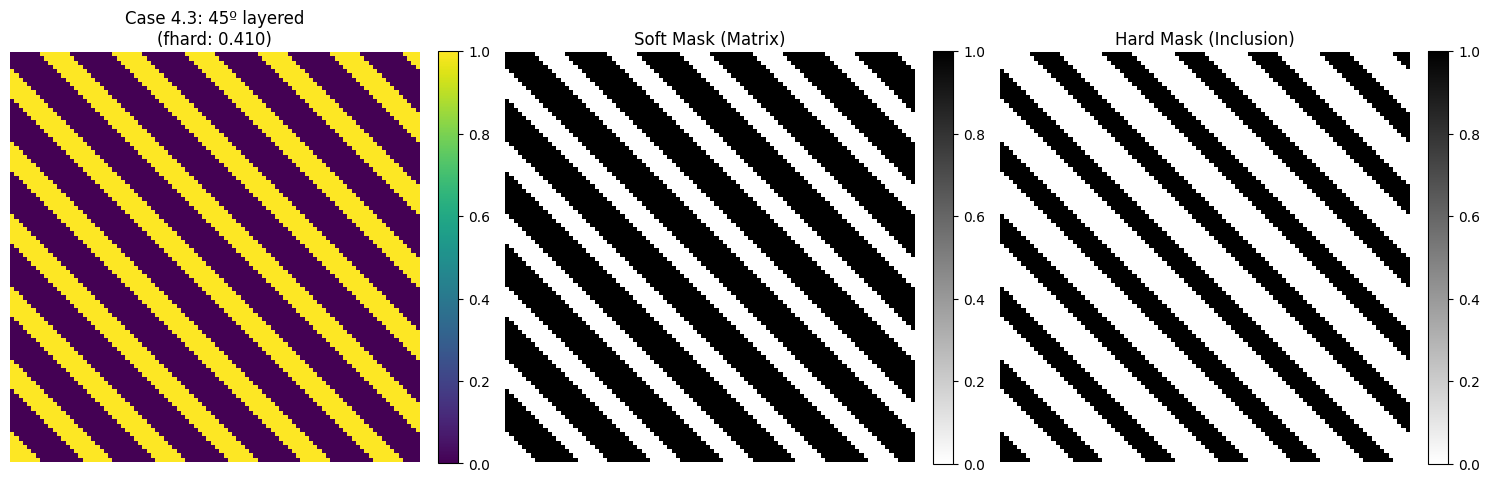

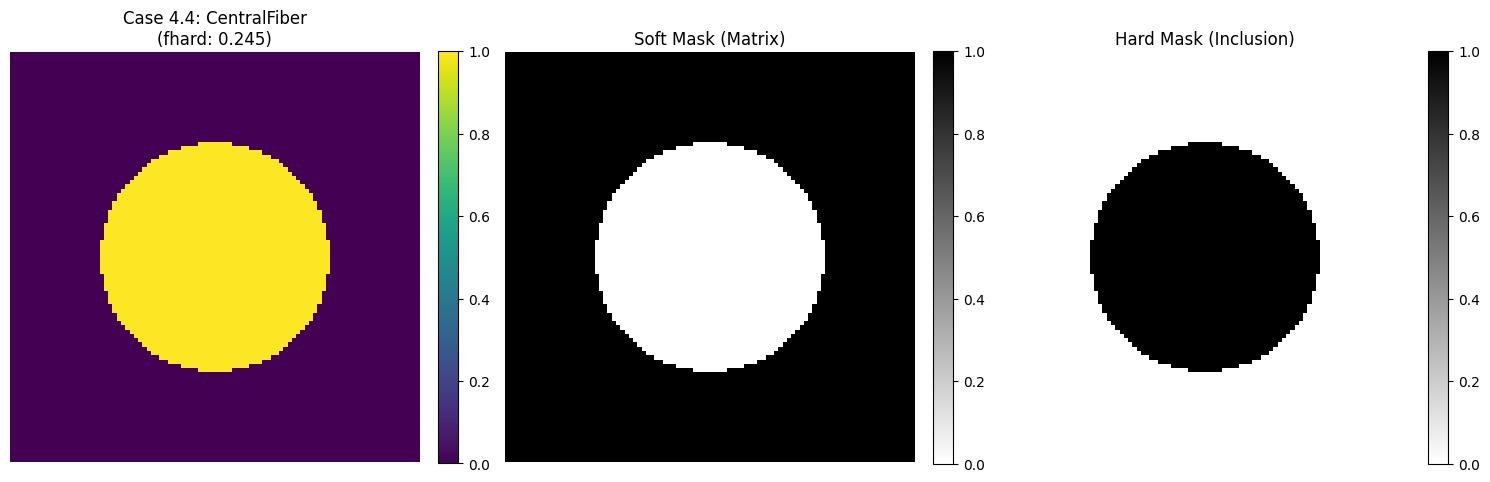

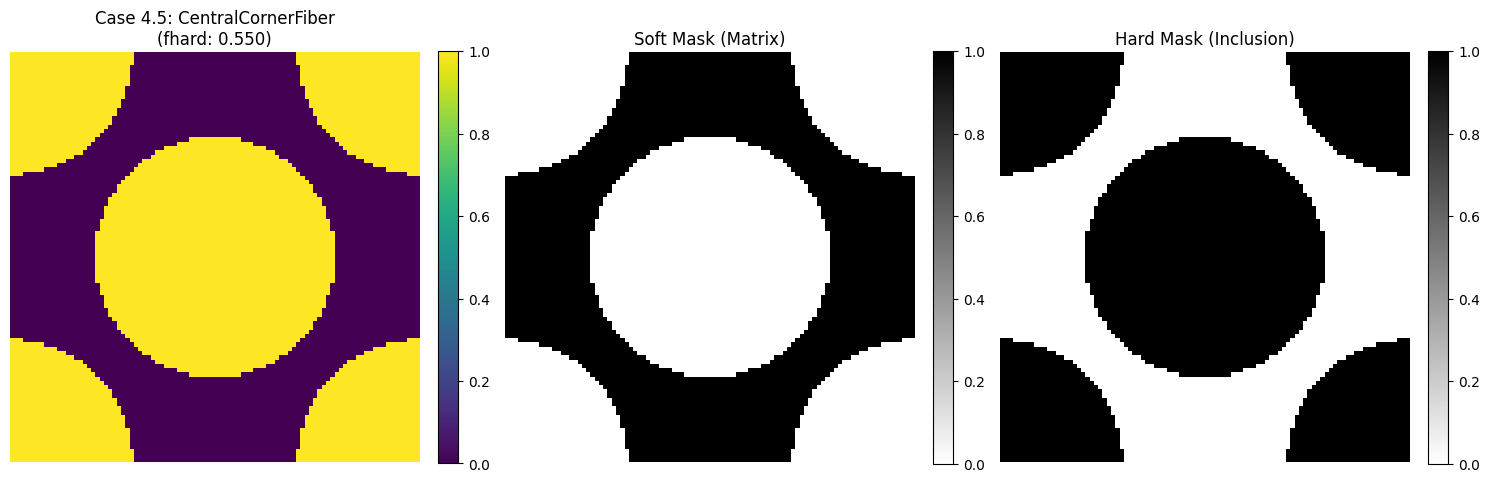

In [3]:
from microstructures import CentralFiber, CentralCornerFiber, RandomBlocks, Layered

# RVE dimensions
delta_x = 0.10      # RVE size in X direction in (mm)
delta_y = 0.10      # RVE size in Y direction in (mm)

NCASES = 0
meshes = []
voxels = []

# --------------------------------------------------------
# Super-resolution and downsampling cases.
# --------------------------------------------------------

# In this cases we evaluate if our trained model in a resolution "r" is able to interpolating accurately to new sampling resolutions.

# 1st case: Random blocks.
# Same as training...
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 1.1: RandomBlocks (nblocks = 8) - Original resolution 96x96")
NCASES += 1

# 2nd case: Random blocks.
# With this cases we evaluate super-resolution capabilities. 
# We double the original resolution.
# We keep constant the number of blocks and the volume fraction of hard phase (0.40).
microstructure.resize(new_resolution=192)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 1.2: RandomBlocks (nblocks = 8) - Upsampling to 192x192")
NCASES += 1

# 3rd case: Random blocks.
# With this cases we evaluate super-resolution capabilities. 
# We half the original resolution.
# We keep constant the number of blocks and the volume fraction of hard phase (0.40).
microstructure.resize(new_resolution=48)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 1.3: RandomBlocks (nblocks = 8) - Downsampling to 48x48")
NCASES += 1

# --------------------------------------------------------
# Material resolution: change in volume fraction
# --------------------------------------------------------

# 4th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the volume fraction of hard phase.
# We keep constant the resolution and the number of blocks. 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.20)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 2.1: RandomBlocks (nblocks = 8) - fhard = 0.20")
NCASES += 1

# 5th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the volume fraction of hard phase.
# We keep constant the resolution and the number of blocks. 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.25)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 2.2: RandomBlocks (nblocks = 8) - fhard = 0.25")
NCASES += 1

# 6th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the volume fraction of hard phase.
# We keep constant the resolution and the number of blocks. 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.30)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 2.3: RandomBlocks (nblocks = 8) - fhard = 0.30")
NCASES += 1

# 7th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the volume fraction of hard phase.
# We keep constant the resolution and the number of blocks. 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.35)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 2.4: RandomBlocks (nblocks = 8) - fhard = 0.35")
NCASES += 1

# 8th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the volume fraction of hard phase.
# We keep constant the resolution and the number of blocks. 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 2.5: RandomBlocks (nblocks = 8) - fhard = 0.40")
NCASES += 1

# 9th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the volume fraction of hard phase.
# We keep constant the resolution and the number of blocks. 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.45)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 2.6: RandomBlocks (nblocks = 8) - fhard = 0.45")
NCASES += 1

# 10th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the volume fraction of hard phase.
# We keep constant the resolution and the number of blocks. 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.50)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 2.7: RandomBlocks (nblocks = 8) - fhard = 0.50")
NCASES += 1

# 11th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the volume fraction of hard phase.
# We keep constant the resolution and the number of blocks. 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.55)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 2.8: RandomBlocks (nblocks = 8) - fhard = 0.55")
NCASES += 1

# 12th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the volume fraction of hard phase.
# We keep constant the resolution and the number of blocks. 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.60)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 2.9: RandomBlocks (nblocks = 8) - fhard = 0.60")
NCASES += 1

# --------------------------------------------------------
# Material resolution: change in number of blocks
# --------------------------------------------------------

# In this cases we evaluate if our trained model with an specific number of frequencies is able to extrapoling accurately to a additional/fewer frequencies present in data.

# 13th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the number of blocks.
# We keep constant the resolution and the volume fraction of hard phase (0.40). 
microstructure = RandomBlocks(resolution=96, n_blocks=16)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 3.1: RandomBlocks (nblocks = 16)")
NCASES += 1

# 14th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the number of blocks.
# We keep constant the resolution and the volume fraction of hard phase (0.40). 
microstructure = RandomBlocks(resolution=96, n_blocks=12)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 3.2: RandomBlocks (nblocks = 12)")
NCASES += 1

# 15th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the number of blocks.
# We keep constant the resolution and the volume fraction of hard phase (0.40). 
microstructure = RandomBlocks(resolution=96, n_blocks=10)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 3.3: RandomBlocks (nblocks = 10)")
NCASES += 1

# 16th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the number of blocks.
# We keep constant the resolution and the volume fraction of hard phase (0.40). 
microstructure = RandomBlocks(resolution=96, n_blocks=8)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 3.4: RandomBlocks (nblocks = 8)")
NCASES += 1

# 17th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the number of blocks.
# We keep constant the resolution and the volume fraction of hard phase (0.40). 
microstructure = RandomBlocks(resolution=96, n_blocks=6)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 3.5: RandomBlocks (nblocks = 6)")
NCASES += 1

# 18th case: Random blocks.
# With this cases we evaluate performance against unseen geometries. 
# We change the number of blocks.
# We keep constant the resolution and the volume fraction of hard phase (0.40). 
microstructure = RandomBlocks(resolution=96, n_blocks=4)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 3.6: RandomBlocks (nblocks = 4)")
NCASES += 1

# --------------------------------------------------------
# Material resolution: change hard phase geometry
# --------------------------------------------------------

# 19th case: Horizontal layered.
# With this cases we evaluate performance against unseen geometries. 
# We keep constant the resolution and the volume fraction of hard phase (0.40).
microstructure = Layered(resolution=96, angle=0.0)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 4.1: horizontal layered")
NCASES += 1

# 20th case: Vertical layered.
# With this cases we evaluate performance against unseen geometries. 
# We keep constant the resolution and the volume fraction of hard phase.
microstructure = Layered(resolution=96, angle=90.0)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 4.2: vertical layered")
NCASES += 1

# 21st case: 45º layered.
# With this cases we evaluate performance against unseen geometries. 
# We keep constant the resolution and the volume fraction of hard phase (0.40).
microstructure = Layered(resolution=96, angle=45.0)
microstructure.generate(fhard=0.40)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 4.3: 45º layered")
NCASES += 1

# 22nd case: Central fiber.
# With this cases we evaluate performance against unseen geometries.
# We modify geometry and the volume fraction of hard phase. 
microstructure = CentralFiber(resolution=96)
microstructure.generate(fhard=0.25)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 4.4: CentralFiber")
NCASES += 1

# 23rd case: Central corner fiber.
# With this cases we evaluate performance against unseen geometries.
# We modify geometry and the volume fraction of hard phase. 
microstructure = CentralCornerFiber(resolution=96)
microstructure.generate(fhard=0.55)
voxels.append(microstructure.phase_tensor)
meshes.append(microstructure.to_mesh(lx=delta_x, ly=delta_y))
microstructure.plot(title=f"Case 4.5: CentralCornerFiber")
NCASES += 1

### Strain histories

In [4]:
from data_generator import StrainHistoryGenerator

# Configuration
n_histories = NCASES
n_steps     = 51
eps_max     = 0.03
theta_max   = np.pi / 6

strain_folder = "../strain_histories/ZeroShot"

generator = StrainHistoryGenerator(
    n_steps=n_steps,
    eps_max=eps_max,
    theta_max=theta_max,
)

histories = generator.generate_multiple_histories(n_histories=n_histories)

generator.save_histories( histories=histories, 
                    prefix = "strain",
                    directory = strain_folder,
                    include_cartesian=True)

Saved 23 histories → columns: step,e1,e2,theta,exx,eyy,gxy 


### Finite element solutions

In [5]:
from conditions import BoundaryCondition
from materials import LinearElastic, NLElasticMatrix
from solver import NFEA

In [ ]:
from conditions import PeriodicBoundaryCondition
import torch
from utils import QuadShapeFunctions
from mesher import Mesh2D

# Material properties

# Soft matrix
tag_soft = 0
K_m = 4_780         # MPa
alpha_1 = 5.0e1     # MPa
alpha_2 = 6.0e-2    # Dimensionless

# Hard fiber
tag_hard = 1 
K_f = 43_500      # MPa
G_f = 29_900      # MPa

E_hard = (9.0 * K_f * G_f) / (3.0 * K_f + G_f)
nu_hard = (3.0 * K_f - 2.0 * G_f) / (2.0 * (3.0 * K_f + G_f))

soft = NLElasticMatrix(Km=K_m, alpha1=alpha_1, alpha2=alpha_2, tag=tag_soft)
hard = LinearElastic(emod=E_hard, nu=nu_hard, tag=tag_hard)

strain_files = sorted(Path(strain_folder).glob("strain_*.csv"))

output_dir = Path("../data/Run2/ZeroShot")
output_dir.mkdir(parents=True, exist_ok=True)

is_running = False

if is_running:
    fem_times = []
    t_total = time.time()

    for idx in range(NCASES):
        t_case = time.time()
        print(f"Processing {idx+1}/{NCASES}", end="  ", flush=True)

        mesh, left_right_pairs, bottom_top_pairs = meshes[idx]
        strain_file = strain_files[idx]

        bcs = {
            'fixed_n': [BoundaryCondition(dof=1, value=0.0),
                        BoundaryCondition(dof=2, value=0.0)],
        }

        strain_data = np.genfromtxt(strain_file, delimiter=',', names=True,
                                    dtype=float, skip_header=0)
        exx = strain_data['exx']
        eyy = strain_data['eyy']
        gxy = strain_data['gxy']
        n_steps = len(exx)

        pbc = PeriodicBoundaryCondition(
            exx=exx[0], eyy=eyy[0], gxy=gxy[0],
            left_right_pairs=left_right_pairs,
            bottom_top_pairs=bottom_top_pairs,
            delta_x=delta_x, delta_y=delta_y,
        )
        mpcs = pbc.get_constraints()

        matfield = {'soft_s': soft, 'hard_s': hard}

        fem_solver = NFEA(mesh=mesh, bcs=bcs, matfld=matfield,
                          mpcs=mpcs, verbose=False, device='cpu')

        rve_file = output_dir / f"rve_zs_{idx:04d}.h5"
        nchannels = 4
        nmacro    = 3
        N_total   = n_steps - 1
        nelx = int(np.sqrt(fem_solver.nelem))
        nely = nelx
        ngp  = 2
        H_gp = nely * ngp
        W_gp = nelx * ngp

        gp_static_list = []
        for group_name, batch in fem_solver.quad_batches.items():
            tag_val = float(batch.material.tag)
            H_shape = QuadShapeFunctions(batch.r_gp, batch.s_gp, batch.nnode)
            X_gp = torch.einsum('gn,enj->egj', H_shape, batch.X)
            coords_flat = X_gp.reshape(-1, 2).cpu().numpy()
            phase_val = 1.0 if tag_val == tag_hard else 0.0
            phase_flat = np.full((len(coords_flat), 1), phase_val, dtype=np.float32)
            gp_static_list.append(np.hstack([coords_flat, phase_flat]))

        gp_static_array = np.vstack(gp_static_list)
        x_coords = np.round(gp_static_array[:, 0], decimals=5)
        y_coords = np.round(gp_static_array[:, 1], decimals=5)
        sort_idx = np.lexsort((x_coords, y_coords))
        phase_grid = gp_static_array[sort_idx, 2].reshape(H_gp, W_gp)

        with h5py.File(rve_file, 'w') as f:
            f.create_dataset('fields', shape=(N_total, H_gp, W_gp, nchannels),
                             dtype=np.float32, compression='gzip', compression_opts=4)
            f.create_dataset('macro', shape=(N_total, nmacro),
                             dtype=np.float32, compression='gzip')
            f.attrs.update({
                'H_gp': H_gp, 'W_gp': W_gp, 'ngp': ngp, 'n_steps': N_total,
                'description': 'Dual-Encoder FNO: '
                               'fields[phase(0=soft,1=hard), sXX, sYY, sXY] + '
                               'macro[exx, eyy, gxy]'
            })

            t_steps = time.time()
            for step in range(1, n_steps):
                pbc.update_strains(new_exx=exx[step], new_eyy=eyy[step], new_gxy=gxy[step])
                fem_solver.update_mpc_b0s()
                fem_solver.run_complete(nsteps=1)

                sigma_list = []
                for group_name, batch in fem_solver.quad_batches.items():
                    u_local  = batch.get_local_disp(fem_solver.udisp)
                    eps_gp   = batch.compute_infinitesimal_strain(u_local)
                    state_gp = batch.state
                    sigma_gp, _, _ = batch.material.update_state(eps_gp, state_gp, isTangent=False)
                    sigma_list.append(sigma_gp.reshape(-1, 3).cpu().numpy())

                sigma_flat   = np.vstack(sigma_list)
                sigma_sorted = sigma_flat[sort_idx]

                data_step = np.zeros((H_gp, W_gp, nchannels), dtype=np.float32)
                data_step[..., 0] = phase_grid
                data_step[..., 1] = sigma_sorted[:, 0].reshape(H_gp, W_gp)
                data_step[..., 2] = sigma_sorted[:, 1].reshape(H_gp, W_gp)
                data_step[..., 3] = sigma_sorted[:, 2].reshape(H_gp, W_gp)

                macro_step = np.array([exx[step], eyy[step], gxy[step]], dtype=np.float32)

                f['fields'][step - 1] = data_step
                f['macro'][step - 1]  = macro_step

        elapsed_case = time.time() - t_case
        elapsed_steps = time.time() - t_steps
        fem_times.append(elapsed_case)
        print(f"{elapsed_case:.1f}s  ({elapsed_steps/N_total:.2f}s/step)")

    total_elapsed = time.time() - t_total
    print(f"\n{'='*48}")
    print(f"  {'Case':>6}  {'Time (s)':>10}  {'s/step':>8}")
    print(f"{'='*48}")
    for i, t in enumerate(fem_times):
        print(f"  {i+1:>6}  {t:>10.1f}  {t/N_total:>8.2f}")
    print(f"{'='*48}")
    print(f"  {'Total':>6}  {total_elapsed:>10.1f}")
    print(f"  {'Mean':>6}  {sum(fem_times)/len(fem_times):>10.1f}")
    print(f"\nFiles saved at: {output_dir}")

In [7]:
# ==================== CHECK FILE ====================

def check_rve_data(rve_file):
    with h5py.File(rve_file, 'r') as f:
        print("✅ File opened successfully")
        print("Available keys        :", list(f.keys()))
        print("File attributes       :")
        for key, val in f.attrs.items():
            print(f"   {key:15} = {val}")
        
        # Datasets
        fields = f['fields'][:]      # (N_steps, H, W, nchannels)
        macro  = f['macro'][:]       # (N_steps, nmacro)
        
        print("\n📊 Shapes:")
        print(f"   fields → {fields.shape}  → [phase(0=soft,1=hard), Sxx, Syy, Sxy]")
        print(f"   macro  → {macro.shape}   → [exx, eyy, gxy]")
        
        H, W = fields.shape[1], fields.shape[2]
        print(f"\n🔍 Grid check: {H}×{W} → {'✅ OK' if H == W else '❌ Not square'}")
        
        # Check phases
        phase_unique = np.unique(fields[0, :, :, 0])
        print(f"   Unique phases: {phase_unique} → {'✅ Correct' if len(phase_unique)==2 else '❌'}")
        
        # First macro values
        print(f"   First macro: exx={macro[0,0]:.6f}, "
              f"eyy={macro[0,1]:.6f}, "
              f"gxy={macro[0,2]:.6f}")
        
        # Last macro values
        print(f"   Last macro: exx={macro[-1,0]:.6f}, "
              f"eyy={macro[-1,1]:.6f}, "
              f"gxy={macro[-1,2]:.6f}")
        return fields, macro

# Test
rve_file = "../data/Run2/ZeroShot/rve_zs_0000.h5"
fields, macro = check_rve_data(rve_file)

✅ File opened successfully
Available keys        : ['fields', 'macro']
File attributes       :
   H_gp            = 96
   W_gp            = 96
   description     = Dual-Encoder FNO: fields[phase(0=soft,1=hard), sXX, sYY, sXY] + macro[exx, eyy, gxy]
   n_steps         = 50
   ngp             = 2

📊 Shapes:
   fields → (50, 96, 96, 4)  → [phase(0=soft,1=hard), Sxx, Syy, Sxy]
   macro  → (50, 3)   → [exx, eyy, gxy]

🔍 Grid check: 96×96 → ✅ OK
   Unique phases: [0. 1.] → ✅ Correct
   First macro: exx=-0.001281, eyy=-0.001696, gxy=0.000730
   Last macro: exx=0.007970, eyy=0.027468, gxy=0.012947


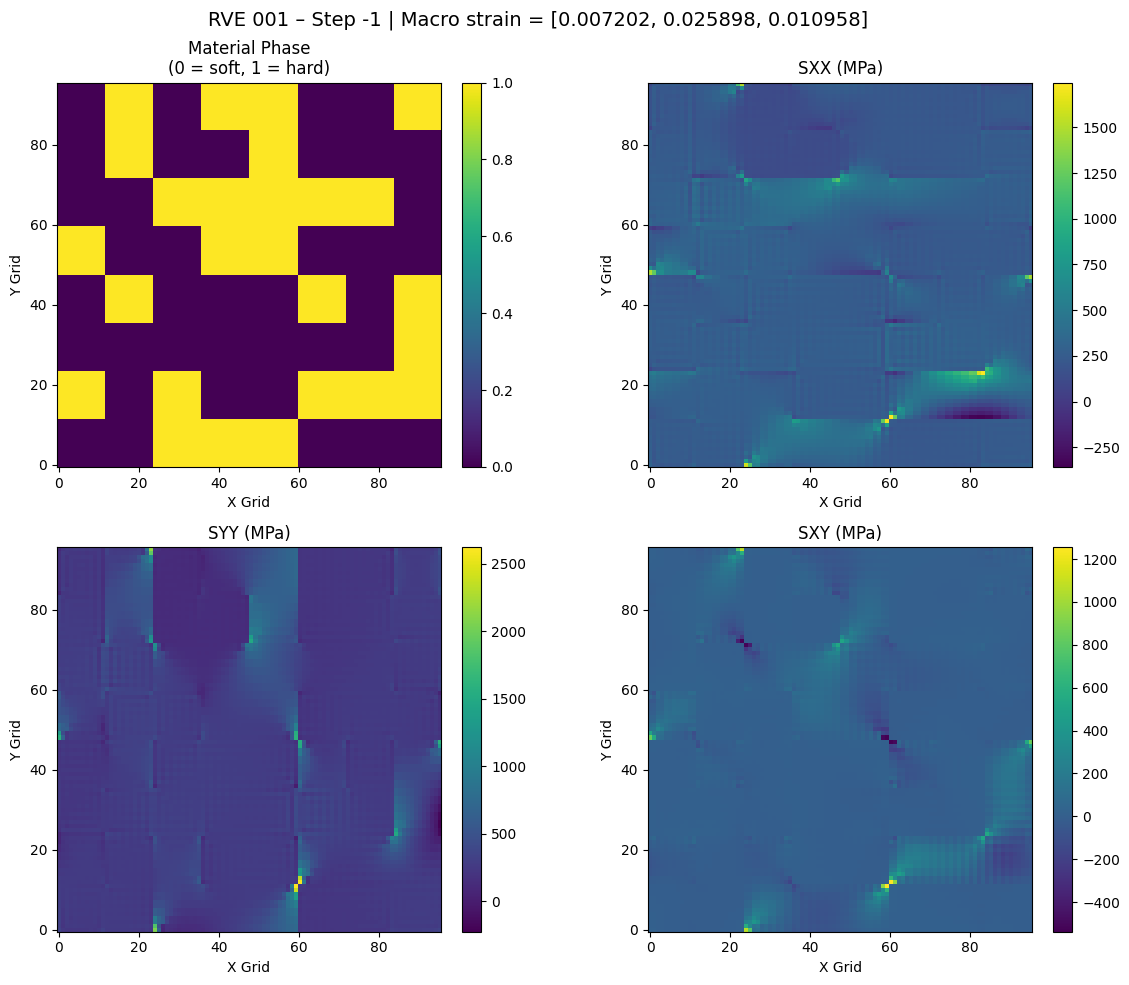

In [8]:
# ==================== PLOTS ====================

def plot_fields(fields, macro, step=-1):
    """
    Plot fields and macro strain for a given step.
    fields: (N_steps, H, W, 4) → [phase, Sxx, Syy, Sxy]
    macro:  (N_steps, 7)      → [exx, eyy, gxy, E_soft, nu_soft, E_hard, nu_hard]
    """
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    titles = [
        "Material Phase\n(0 = soft, 1 = hard)",
        "SXX (MPa)",
        "SYY (MPa)",
        "SXY (MPa)"
    ]
    
    data = [
        fields[step-1, :, :, 0],   # phase
        fields[step-1, :, :, 1],   # σxx
        fields[step-1, :, :, 2],   # σyy
        fields[step-1, :, :, 3]    # σxy
    ]

    for i, ax in enumerate(axs.flat):
        im = ax.imshow(data[i], cmap='viridis', origin='lower')
        ax.set_title(titles[i])
        ax.set_xlabel('X Grid')
        ax.set_ylabel('Y Grid')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Show only macro strain components in title
    eps = macro[step-1, :3]  # exx, eyy, gxy
    plt.suptitle(f'RVE 001 – Step {step} | '
                 f'Macro strain = [{eps[0]:.6f}, {eps[1]:.6f}, {eps[2]:.6f}]',
                 fontsize=14)
    
    plt.tight_layout()
    plt.show()


# Test
plot_fields(fields, macro, step=-1)

In [9]:
import torch
import h5py
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from neuralop import LpLoss, H1Loss
from rve_analyzer import DualEncoderFNO, RVEInferencer, RVEVisualizer, HomogenizedLoss

In [10]:
from types import SimpleNamespace

cfg = SimpleNamespace(**{})

cfg.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {cfg.device}")

cfg.batch_size = 64
cfg.num_workers = 0

Device: cuda


In [11]:
def load_trained_model(checkpoint_dir: str = "../checkpoints", model_name_prefix: str = "rve_fno"):
    
    path = Path(checkpoint_dir)
    
    # Load and instance model
    config = torch.load(path / f"{model_name_prefix}_config.pth", weights_only=False)
    model = DualEncoderFNO(**config)
    
    # Load Weights and Bias
    checkpoint = torch.load(path / f"{model_name_prefix}_params.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Load normalizers
    normalizers = torch.load(path / f"{model_name_prefix}_normalizers.pth", weights_only=False)
    
    return model, normalizers

model, normalizers = load_trained_model(model_name_prefix="rve2_fno_v8")
model.to(cfg.device)
print("Model and normalizers loaded.")

Model and normalizers loaded.


In [12]:

class ZeroShotDataset(Dataset):
    """
    Versión corregida para Zero-Shot.
    Fuerza las shapes correctas de mean/std (igual que en RVEDataset).
    """
    def __init__(self, h5_path: str | Path, normalizers: dict):
        
        self.h5_path = Path(h5_path)
        
        self.x_normalizer     = normalizers['x_normalizer'].to('cpu')
        self.global_normalizer = normalizers['global_normalizer'].to('cpu')
        self.y_normalizer     = normalizers['y_normalizer'].to('cpu')

        if self.x_normalizer.mean.ndim == 1:
            self.x_normalizer.mean = self.x_normalizer.mean.view(-1, 1, 1)
            self.x_normalizer.std  = self.x_normalizer.std.view(-1, 1, 1)

        if self.y_normalizer.mean.ndim == 1:
            self.y_normalizer.mean = self.y_normalizer.mean.view(-1, 1, 1)
            self.y_normalizer.std  = self.y_normalizer.std.view(-1, 1, 1)

        with h5py.File(self.h5_path, 'r') as f:
            fields = f['fields'][:]      # (N, H, W, 4)
            macro  = f['macro'][:]       # (N, 3)

        self.N = fields.shape[0]

        fields = torch.from_numpy(fields).float()
        macro  = torch.from_numpy(macro).float()

        self.x_local  = fields[:, :, :, 0:1]   # (N, H, W, 1)
        self.y_local  = fields[:, :, :, 1:4]   # (N, H, W, 3)
        self.x_global = macro

        # channels-last → channels-first
        self.x_local = self.x_local.permute(0, 3, 1, 2).contiguous()
        self.y_local = self.y_local.permute(0, 3, 1, 2).contiguous()

        # Normalización
        self.x_local  = self.x_normalizer.transform(self.x_local)
        self.x_global = self.global_normalizer.transform(self.x_global)
        self.y_local  = self.y_normalizer.transform(self.y_local)

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        return (
            self.x_local[idx],
            self.x_global[idx],
            self.y_local[idx]
        )

In [13]:
@torch.inference_mode()
def evaluate_model(model, dataloader, device, l2_loss, h1_loss, hg_loss):
    model.eval()
    total_l2 = 0.0
    total_h1 = 0.0
    total_hg = 0.0
    total_samples = 0
    
    for batch in dataloader:
        x_local, x_global, y_local = batch
        x_local = x_local.to(device)
        x_global = x_global.to(device)
        y_local = y_local.to(device)
        
        pred = model(x_local, x_global)
        
        batch_l2 = l2_loss(pred, y_local).item()
        batch_h1 = h1_loss(pred, y_local).item()
        batch_hg = hg_loss(pred, y_local).item()
        batch_size = x_local.size(0)
        
        total_l2 += batch_l2 * batch_size
        total_h1 += batch_h1 * batch_size
        total_hg += batch_hg * batch_size        
        total_samples += batch_size
    
    avg_l2 = total_l2 / total_samples
    avg_h1 = total_h1 / total_samples
    avg_hg = total_hg / total_samples
    
    return avg_l2, avg_h1, avg_hg

In [ ]:
l2loss = LpLoss(d=2, p=2, reduction='mean')
h1loss = H1Loss(d=2, reduction='mean')
hgloss = HomogenizedLoss()

persistent_workers = True if cfg.num_workers > 0 else False
prefetch_factor = 4 if cfg.num_workers > 0 else None

eval_times = []
t_total = time.time()

for idx in range(NCASES):
    t_case = time.time()
    print(f"\n--- Zero-Shot Case {idx+1}/{NCASES} ---")
    file_path = output_dir / f"rve_zs_{idx:04d}.h5"

    # Dataset + DataLoader
    t0 = time.time()
    zs_dataset = ZeroShotDataset(file_path, normalizers)
    zs_loader  = DataLoader(zs_dataset, batch_size=cfg.batch_size, shuffle=False,
                            num_workers=cfg.num_workers, pin_memory=True,
                            persistent_workers=persistent_workers,
                            prefetch_factor=prefetch_factor)
    t_load = time.time() - t0

    # Evaluation
    t0 = time.time()
    test_l2, test_h1, test_hg = evaluate_model(model, zs_loader, cfg.device,
                                                l2loss, h1loss, hgloss)
    t_eval = time.time() - t0
    print(f"  L2: {test_l2:.6f}  H1: {test_h1:.6f}  Hg: {test_hg:.6f}")

    # Inference
    y_norm = normalizers['y_normalizer'].to('cpu')
    if y_norm.mean.ndim > 1:
        y_norm.mean = y_norm.mean.squeeze()
        y_norm.std  = y_norm.std.squeeze()
    inferencer = RVEInferencer(model, y_norm, device=cfg.device)

    t0 = time.time()
    y_true, y_pred = inferencer.predict_dataset(zs_loader)
    t_infer = time.time() - t0

    elapsed = time.time() - t_case
    eval_times.append(elapsed)
    print(f"  Load: {t_load:.2f}s  |  Eval: {t_eval:.2f}s  |  "
          f"Infer: {t_infer:.2f}s  |  Total: {elapsed:.2f}s")

    print(f"  y_true: {y_true.shape}  y_pred: {y_pred.shape}")

    phase_array = np.array([zs_dataset[i][0].numpy() for i in range(len(zs_dataset))])

    step_to_plot = -1
    for i in range(3):
        RVEVisualizer.plot_contours(
            phase=phase_array, y_true=y_true, y_pred=y_pred,
            index=step_to_plot, channel=i, cmap='jet',
        )
    RVEVisualizer.plot_cross_sections(phase_array, y_true, y_pred,
                                      index=step_to_plot, variable='Stress')

# Summary
total_elapsed = time.time() - t_total
print(f"\n{'='*44}")
print(f"  {'Case':>6}  {'Time (s)':>10}")
print(f"{'='*44}")
for i, t in enumerate(eval_times):
    print(f"  {i+1:>6}  {t:>10.2f}")
print(f"{'='*44}")
print(f"  {'Total':>6}  {total_elapsed:>10.2f}s")
print(f"  {'Mean':>6}  {sum(eval_times)/len(eval_times):>10.2f}s")